In [1]:
import pandas as pd
data ={
    "Years of experience":[1.2,1.4,1.6,2.1,2.3,2.7,2.9,3.0,3.3,3.4,3.7,3.9,4.6,4.8,5.0],
    "Salary":[39344.0,40206.0,38732.0,42526.0,39892.0,41362.0,45678.0,42308.0,44876.0,48769.0,47590.0,49678.0,49876.0,52986.0,50987.0]
}
df=pd.DataFrame(data)
print(df)
df.to_csv("experience.csv",index=False)

    Years of experience   Salary
0                   1.2  39344.0
1                   1.4  40206.0
2                   1.6  38732.0
3                   2.1  42526.0
4                   2.3  39892.0
5                   2.7  41362.0
6                   2.9  45678.0
7                   3.0  42308.0
8                   3.3  44876.0
9                   3.4  48769.0
10                  3.7  47590.0
11                  3.9  49678.0
12                  4.6  49876.0
13                  4.8  52986.0
14                  5.0  50987.0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [6]:
df=pd.read_csv("experience.csv")

In [7]:
df.head()

,Years of experience,Salary
0,1.2,39344.0
1,1.4,40206.0
2,1.6,38732.0
3,2.1,42526.0
4,2.3,39892.0


In [8]:
df.isnull().sum()

Years of experience    0
Salary                 0
dtype: int64

<Axes: xlabel='Years of experience', ylabel='Salary'>

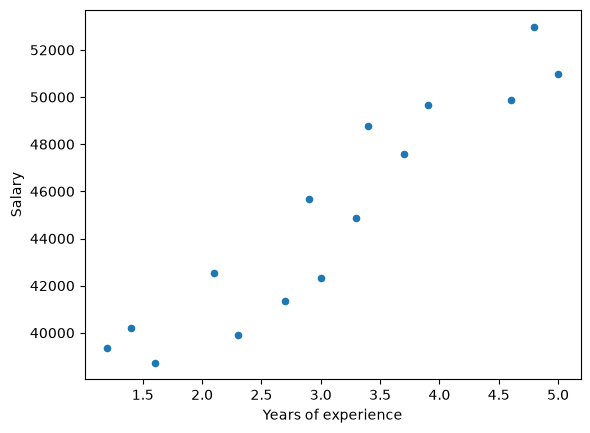

In [9]:
df.plot(kind="scatter",x="Years of experience",y="Salary")

In [10]:
x=df[["Years of experience"]]
y=df[["Salary"]]  #creating the x and y values

In [11]:
#split the data into training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
x_train.shape

(12, 1)

In [13]:
df.shape

(15, 2)

In [14]:
x_test.shape

(3, 1)

In [15]:
#create the model
model=LinearRegression()

In [16]:
#train the model
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[3690.07]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Years of experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[33250.87]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
#Use the trained model to predict
y_pred=model.predict(x_test)

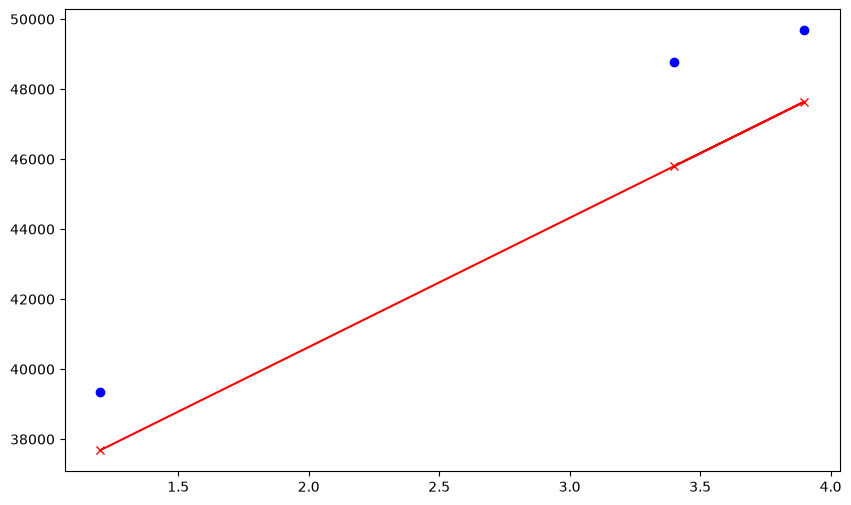

In [18]:
#compare predicted values with the actual values
plt.figure(figsize=(10,6))
plt.scatter(x=x_test,y=y_test,label="Actual values",color="blue",marker="o")

#plot predicted values
plt.plot(x_test,y_pred,label="Predicted values",color="Red",marker="x")

In [19]:
y_pred.shape

(3, 1)

In [20]:
print(model.intercept_)
print(model.coef_)

[33250.87409626]
[[3690.06713489]]


In [21]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("Mean squared error")
print(mean_squared_error(y_test,y_pred))
print("R_squared")
print(r2_score(y_test,y_pred))
print("Mean absolute error")
print(mean_absolute_error(y_test,y_pred))

Mean squared error
5249764.715424238
R_squared
0.7594896801033844
Mean absolute error
2224.2690215520197
